In [307]:
import warnings
warnings.filterwarnings('ignore')

import numpy as N
import pandas as P
import matplotlib.pyplot as PLOT
import seaborn as S

In [308]:
D = P.read_csv ("SMSD.csv")

In [309]:
print(D.columns)

Index(['Post_ID', 'Platform', 'Topic', 'Post_Text', 'Likes', 'Shares',
       'Sentiment', 'Date'],
      dtype='object')


In [310]:
print(D.shape)

(10000, 8)


In [311]:
print(D.dtypes)

Post_ID       int64
Platform     object
Topic        object
Post_Text    object
Likes         int64
Shares        int64
Sentiment    object
Date         object
dtype: object


In [312]:
NV = D.isnull().sum()
print(NV)

Post_ID      0
Platform     0
Topic        0
Post_Text    0
Likes        0
Shares       0
Sentiment    0
Date         0
dtype: int64


In [313]:
DV = D.duplicated().sum()
print(DV)

0


In [314]:
from sklearn.preprocessing import LabelEncoder

In [315]:
LE = LabelEncoder ()

In [316]:
D["Platform"] = LE.fit_transform (D["Platform"])
D["Post_Text"] = LE.fit_transform (D["Post_Text"])
D["Topic"] = LE.fit_transform (D["Topic"])
D["Sentiment"] = LE.fit_transform (D["Sentiment"])
D["Date"] = LE.fit_transform (D["Date"])

In [317]:
print(D.dtypes)

Post_ID      int64
Platform     int64
Topic        int64
Post_Text    int64
Likes        int64
Shares       int64
Sentiment    int64
Date         int64
dtype: object


In [318]:
X = D.drop ("Sentiment", axis = 1)
Y = D["Sentiment"]

In [319]:
from sklearn.model_selection import train_test_split

In [320]:
X_Train , X_Test , Y_Train , Y_Test = train_test_split (X , Y , test_size = 0.2 , random_state = 42)

In [321]:
print(X_Train.shape)
print(X_Test.shape)
print(Y_Train.shape)
print(Y_Test.shape)

(8000, 7)
(2000, 7)
(8000,)
(2000,)


In [322]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

In [323]:
M1 = LogisticRegression ()
M2 = LinearRegression ()
M3 = RandomForestClassifier ()
F1 = M1.fit (X_Train , Y_Train)
F2 = M2.fit (X_Train , Y_Train)
F3 = M3.fit (X_Train , Y_Train)
print(M1)
print(M2)
print(M3)
print(F1)
print(F2)
print(F3)

LogisticRegression()
LinearRegression()
RandomForestClassifier()
LogisticRegression()
LinearRegression()
RandomForestClassifier()


In [324]:
PRE_1 = F1.predict (X_Test)
PRE_2 = F2.predict (X_Test)
PRE_3 = F3.predict (X_Test)
print(PRE_1)
print(PRE_2)
print(PRE_3)

[0 2 1 ... 1 0 1]
[0.64924565 1.52729672 0.58741085 ... 0.52905548 0.67614855 0.9136459 ]
[0 2 1 ... 0 0 1]


In [325]:
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error

In [326]:
R2_1 = r2_score (Y_Test , PRE_1)
print(R2_1 * 100 , "%")
MSE_1 = mean_squared_error (Y_Test , PRE_1)
print(MSE_1)
MAE_1 = mean_absolute_error (Y_Test , PRE_1)
print(MAE_1)
RMSE_1 = N.sqrt(MSE_1)
print(RMSE_1)
print("\n")
R2_2 = r2_score (Y_Test , PRE_2)
print(R2_2 * 100 , "%")
MSE_2 = mean_squared_error (Y_Test , PRE_2)
print(MSE_2)
MAE_2 = mean_absolute_error (Y_Test , PRE_2)
print(MAE_2)
RMSE_2 = N.sqrt(MSE_2)
print(RMSE_2)
print("\n")
R2_3 = r2_score (Y_Test , PRE_3)
print(R2_3 * 100 , "%")
MSE_3 = mean_squared_error (Y_Test , PRE_3)
print(MSE_3)
MAE_3 = mean_absolute_error (Y_Test , PRE_3)
print(MAE_3)
RMSE_3 = N.sqrt(MSE_3)
print(RMSE_3)

-25.9235597354051 %
0.8505
0.5215
0.9222255689363639


22.96523370845629 %
0.5203003224227994
0.6024765169793936
0.7213184611687126


96.3725723533011 %
0.0245
0.0245
0.15652475842498528


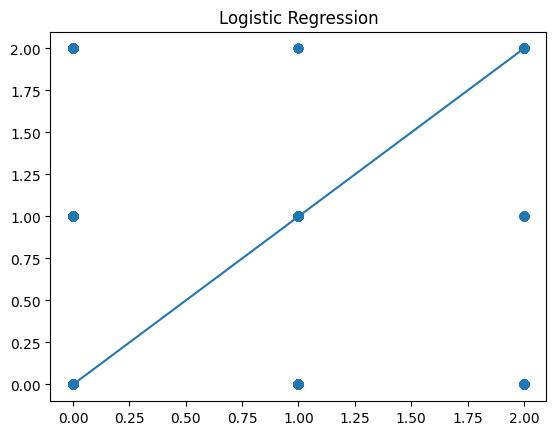

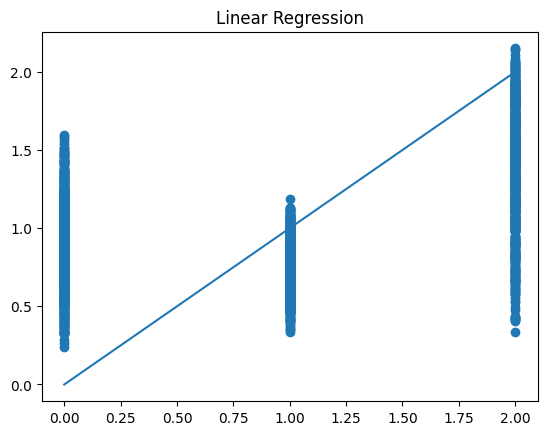

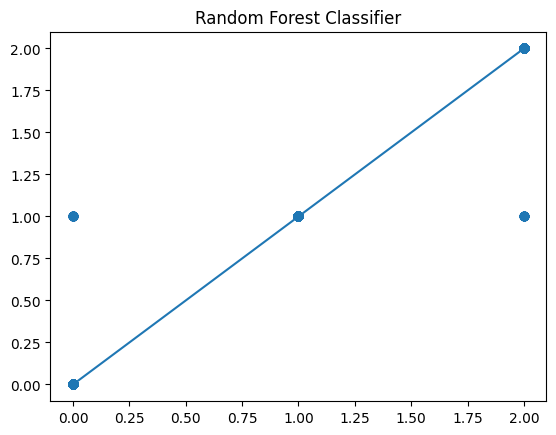

In [327]:
PLOT.scatter (Y_Test , PRE_1)
PLOT.plot([Y_Test.min() , Y_Test.max()] , [Y_Test.min() , Y_Test.max()])
PLOT.title ("Logistic Regression")
PLOT.show ()
print("\n")
PLOT.scatter (Y_Test , PRE_2)
PLOT.plot([Y_Test.min() , Y_Test.max()] , [Y_Test.min() , Y_Test.max()])
PLOT.title ("Linear Regression")
PLOT.show ()
print("\n")
PLOT.scatter (Y_Test , PRE_3)
PLOT.plot([Y_Test.min() , Y_Test.max()] , [Y_Test.min() , Y_Test.max()])
PLOT.title ("Random Forest Classifier")
PLOT.show ()

In [328]:
print(D.dtypes)

Post_ID      int64
Platform     int64
Topic        int64
Post_Text    int64
Likes        int64
Shares       int64
Sentiment    int64
Date         int64
dtype: object


In [329]:
PRE_T_1 = F1.predict ([[101, 1, 3, 245, 5200, 860, 20240511]])
PRE_T_2 = F2.predict ([[101, 1, 3, 245, 5200, 860, 20240511]])
PRE_T_3 = F3.predict ([[101, 1, 3, 245, 5200, 860, 20240511]])
print(PRE_T_1)
print(PRE_T_2)
print(PRE_T_3)

[1]
[442.10476005]
[2]


In [330]:
SF = D.to_csv ("Sentiment Analysis Dataset P.csv" , index = False)